In [1]:
import os
import sys
import re

import numpy as np
import matplotlib.pyplot as plt
import tidy3d as td
from dotenv import load_dotenv

load_dotenv()

# Add parent project path so AutomationModule is importable
sys.path.append(os.path.abspath(fr'../../../../tidy3d'))
from AutomationModule import *
import AutomationModule as AM

tidy3dAPI = os.environ["API_TIDY3D_KEY"]

In [2]:
dir = rf"./data/diffraction_monitor_data"
# transmission_folder = f"{dir}/20260422_diffraction_n_3.4_ff_0.2172_ffh_0.225_schulz.h5"
transmission_folder = f"{dir}/20260708_diffraction_n_3.4_ff_0.237_ffh_0.185_schulz.h5"


In [3]:
transmission_dict = AM.read_hdf5_as_dict(filename=transmission_folder)
transmission_dict["transmission_data"].keys()

dict_keys(['3.4'])

Processing n=3.4


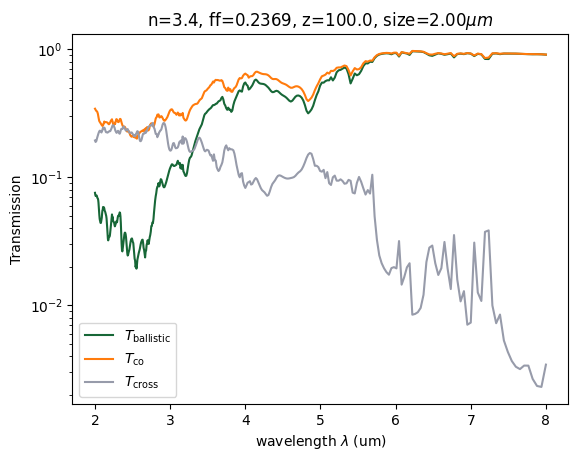

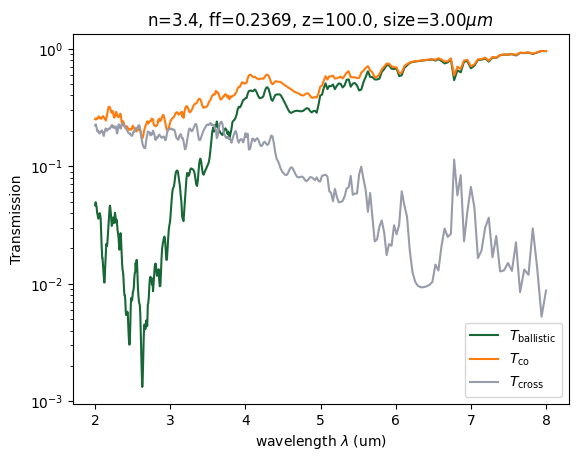

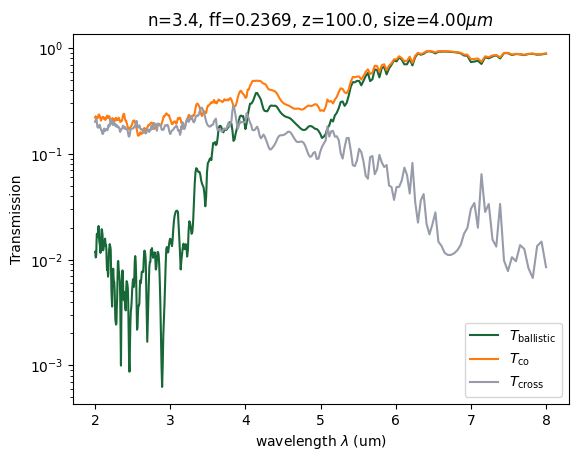

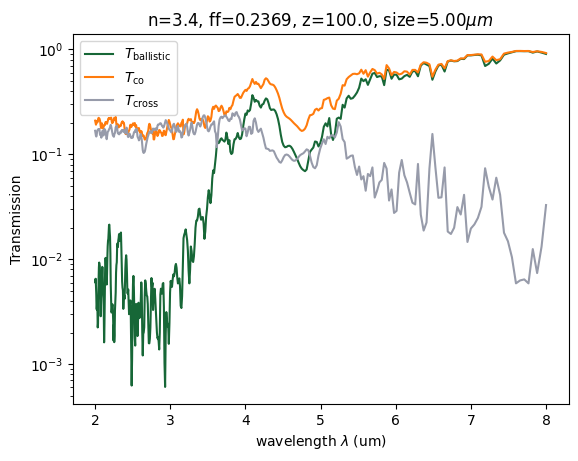

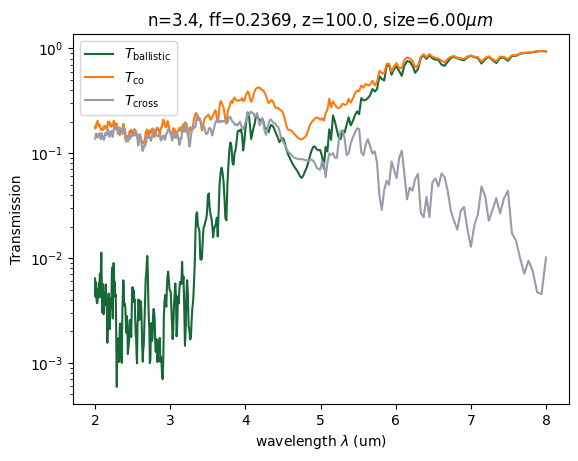

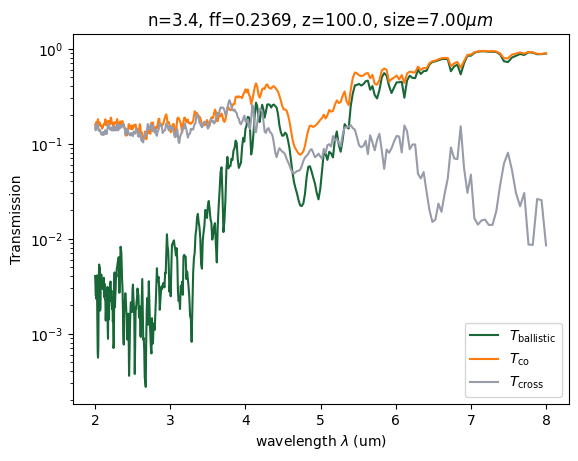

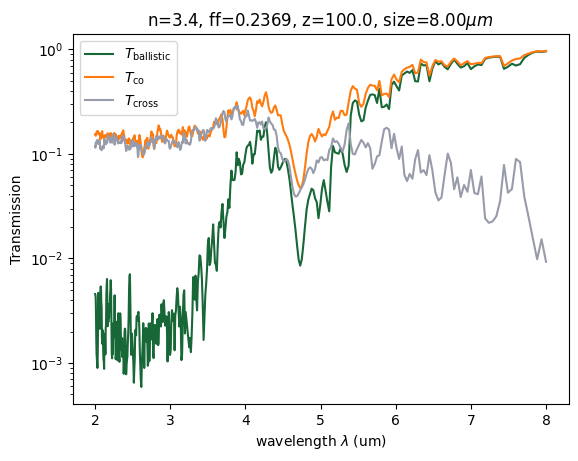

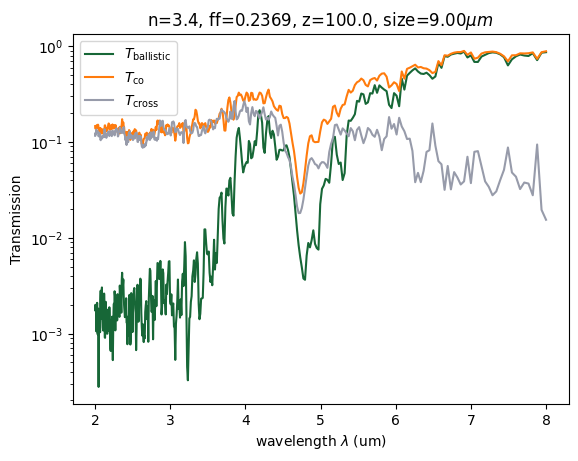

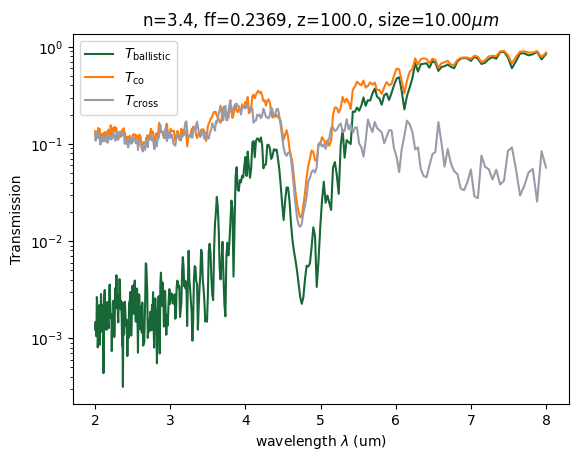

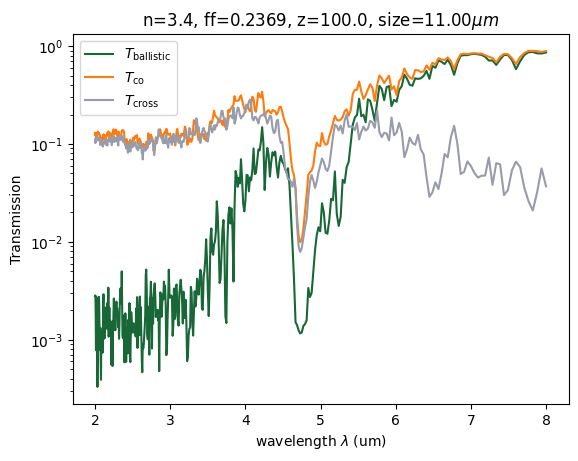

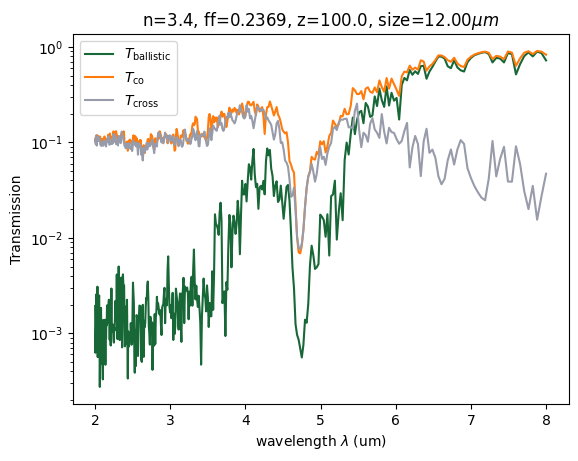

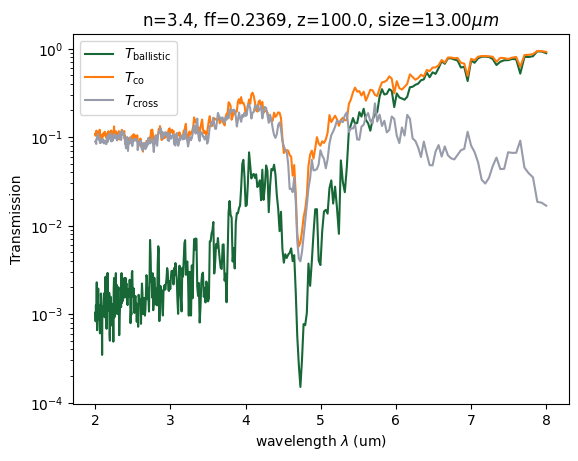

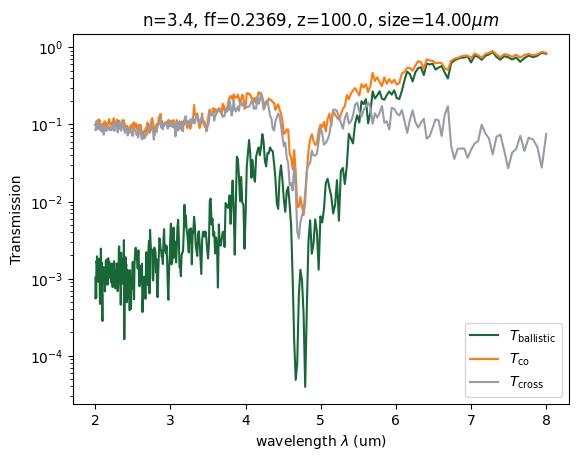

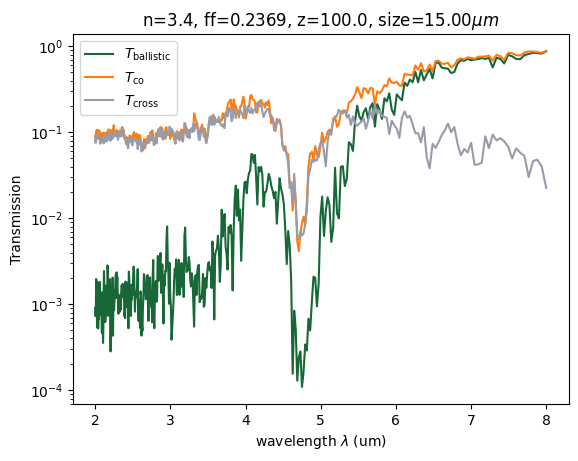

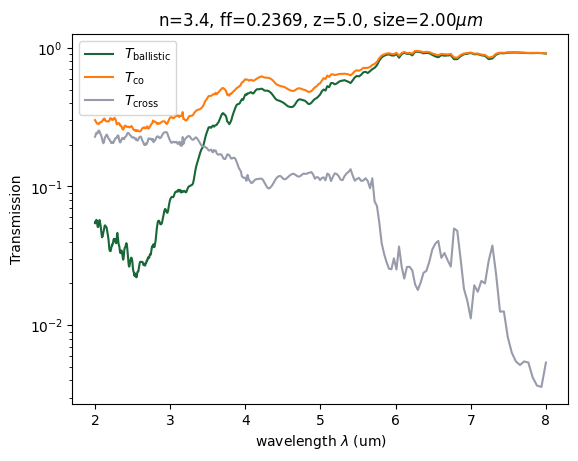

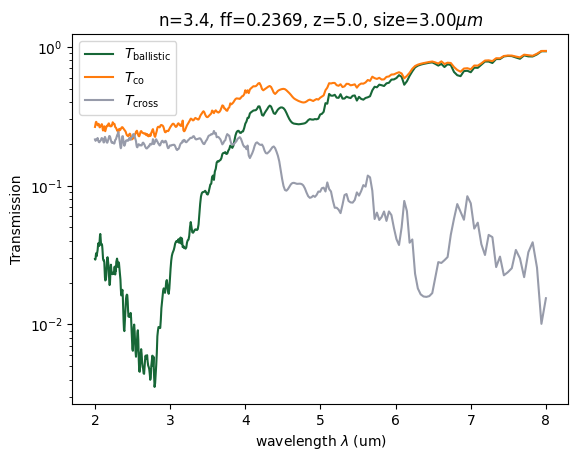

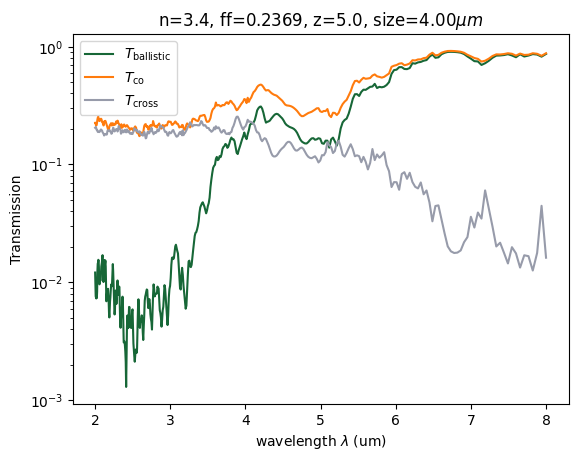

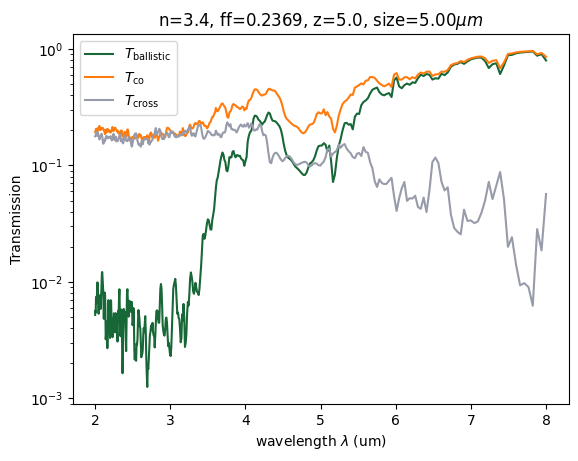

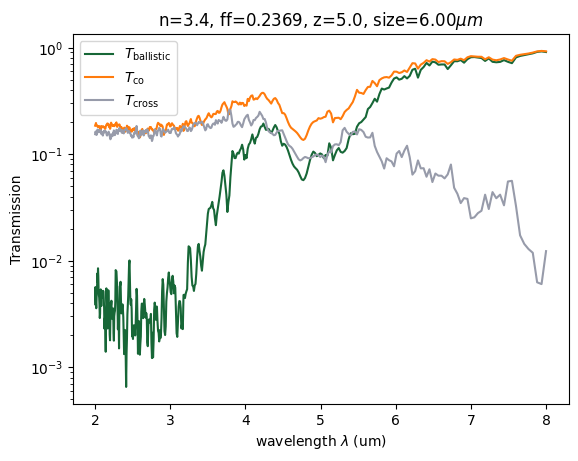

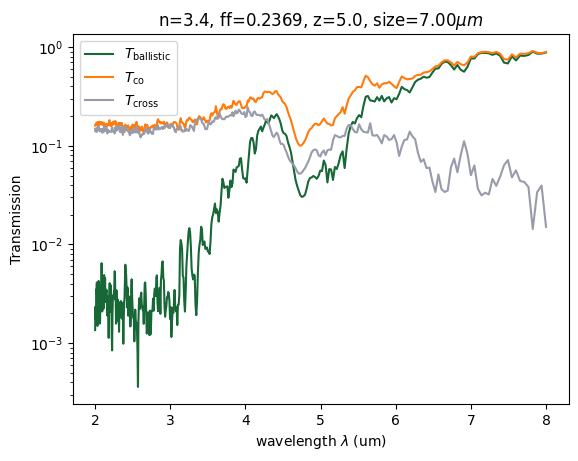

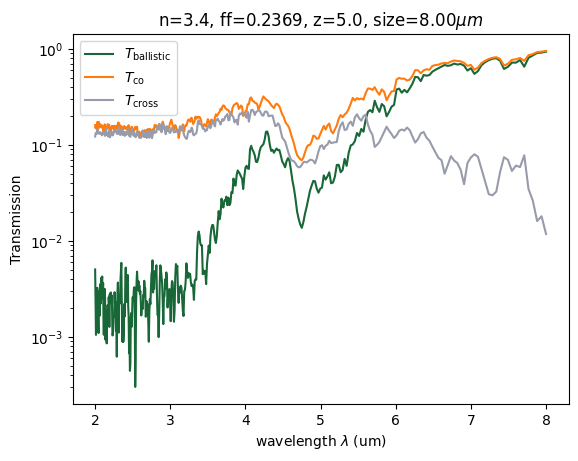

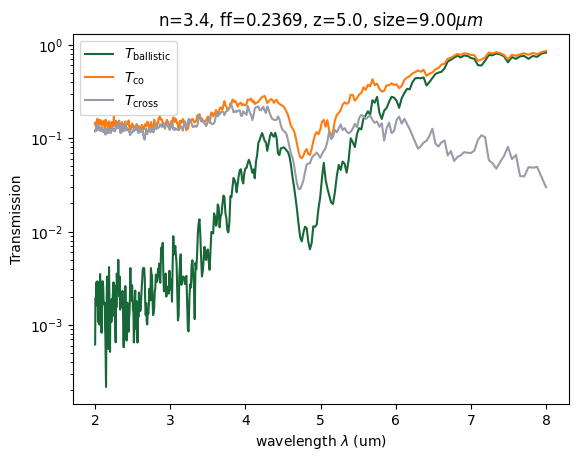

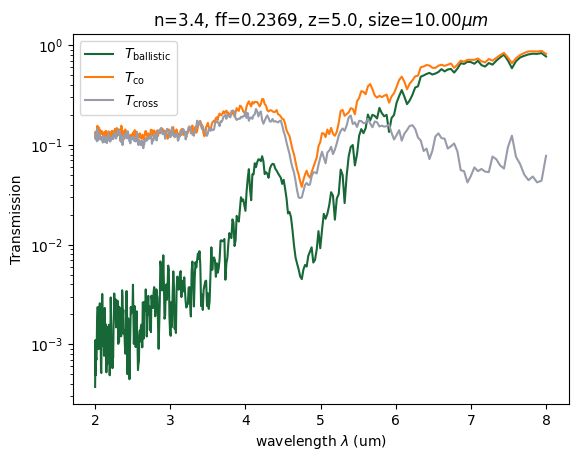

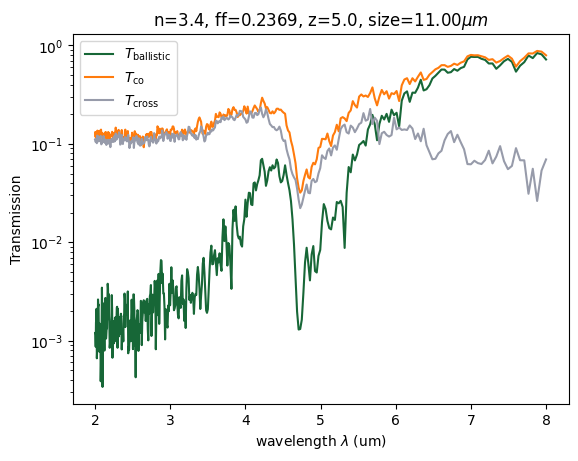

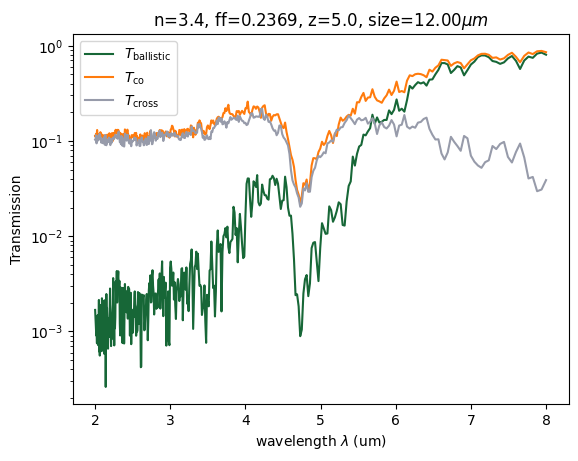

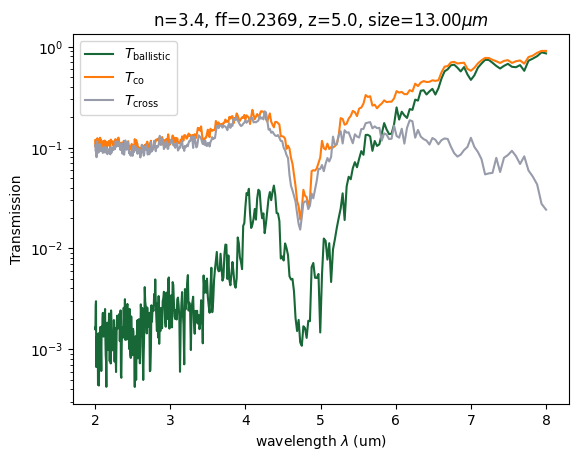

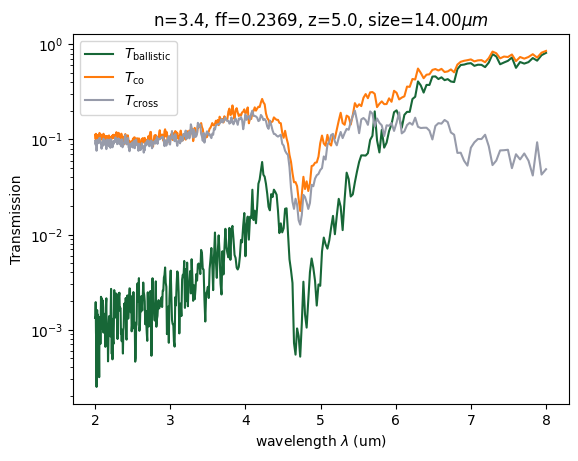

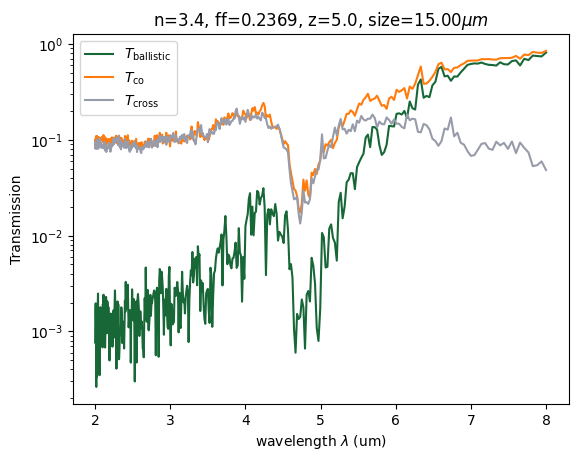

In [5]:
titles = [r"$T_{\mathrm{ballistic}}$", r"$T_{\mathrm{co}}$", r"$T_{\mathrm{cross}}$", r"$T_{\mathrm{total}}$"]
component_keys = ["T_ballistic", "T_co", "T_cross", "T_total"]
lambdas = transmission_dict["lambdas"]

for n in transmission_dict["transmission_data"].keys():
    print(f"Processing n={n}")
    for ff in transmission_dict["transmission_data"][n].keys():
        for z in transmission_dict["transmission_data"][n][ff].keys():
            for size in transmission_dict["transmission_data"][n][ff][z].keys():
                transmission_average = np.array([np.mean([transmission_dict["transmission_data"][n][ff][z][size][s][key] 
                                                         for s in transmission_dict["transmission_data"][n][ff][z][size].keys()],axis=0) for key in component_keys])
                plt.plot(lambdas, transmission_average[0], label=titles[0])
                plt.plot(lambdas, transmission_average[1], label=titles[1])
                plt.plot(lambdas, transmission_average[2], label=titles[2])
                # plt.plot(lambdas, transmission_average[3], label=titles[3]) #Total Transmission
                # plt.plot(lambdas, transmission_average[1] + transmission_average[2], label=r"$T_{\mathrm{co}}+T_{\mathrm{cross}}$") 
                plt.title(rf"n={n}, ff={ff}, z={z}, size={float(size)*11.44:.2f}$\mu m$")
                plt.legend()
                plt.xlabel(rf"wavelength $\lambda$ (um)")
                plt.ylabel("Transmission")
                plt.yscale("log")
                save_dir=rf"{dir}/20260708_Transmission_Components_L_ff_{ff}_n_{n}/z_{z}"
                os.makedirs(save_dir,exist_ok=True)
                plt.savefig(rf"{save_dir}/transmission_n_{n}_ff_{ff}_z_{z}_Transmission_Components_average_L_{float(size)*11.44:.2f}.png")
                plt.show()
                T_array = np.vstack([lambdas, *transmission_average])
                str_T = " ".join(component_keys)
                np.savetxt(f"{save_dir}/transmission_n_{n}_ff_{ff}_z_{z}_Transmission_Components_average_L_{float(size)*11.44:.2f}.txt", np.transpose(T_array), 
                    fmt="%.18f", 
                    delimiter=" ", 
                    header="lambda " +str_T )

                